In [3]:
import pandas as pd

# Load the two separate files
gen_df = pd.read_csv("Plant_1_Generation_Data.csv")
weather_df = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

# --- IMPORTANT ---
# Convert the text 'DATE_TIME' columns into real datetime objects
gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Merge them into one master table on the 'DATE_TIME' column
df = pd.merge(gen_df, weather_df, on='DATE_TIME', how='inner')

# Check for any missing data
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Simple way to clean: drop any rows that have missing data
df = df.dropna()

print("\n--- Merged Data Ready ---")
print(df.head())


--- Missing Values Check ---
DATE_TIME              0
PLANT_ID_x             0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_y             0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

--- Merged Data Ready ---
   DATE_TIME  PLANT_ID_x     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15     4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15     4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15     4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15     4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15     4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  PLANT_ID_y     SOURCE_KEY_y  AMBIENT_TEMPERATURE  \
0    6259559.0     4135001  HmiyD2TTLFNqkNe            25.184316   
1    6183645.0     4135001

/tmp/ipython-input-105821349.py:9: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen_df['DATE_TIME'] = pd.to_datetime(gen_df['DATE_TIME'])


In [4]:
# --- 1. Filter for Daylight Hours ---
# We only want to predict power when the sun is out.
# This simplifies the problem and makes our model more accurate.
df_daylight = df[df['IRRADIATION'] > 0.01].copy()

# --- 2. Create Time-Based Features ---
# The model needs numbers, not datetimes.
df_daylight['hour'] = df_daylight['DATE_TIME'].dt.hour
df_daylight['month'] = df_daylight['DATE_TIME'].dt.month

print("\n--- Data with New Features ---")
print(df_daylight.head())


--- Data with New Features ---
              DATE_TIME  PLANT_ID_x     SOURCE_KEY_x    DC_POWER   AC_POWER  \
531 2020-05-15 06:15:00     4135001  1BY6WEcLGh8j5v7  278.000000  26.862500   
532 2020-05-15 06:15:00     4135001  1IF53ai7Xc0U56Y  310.571429  30.014286   
533 2020-05-15 06:15:00     4135001  3PZuoBAID5Wc2HD  318.625000  30.775000   
534 2020-05-15 06:15:00     4135001  7JYdWkrLSPkdwr4  316.250000  30.562500   
535 2020-05-15 06:15:00     4135001  McdE0feGgRqW7Ca  311.428571  30.100000   

     DAILY_YIELD  TOTAL_YIELD  PLANT_ID_y     SOURCE_KEY_y  \
531     2.625000  6259561.625     4135001  HmiyD2TTLFNqkNe   
532     3.000000  6183648.000     4135001  HmiyD2TTLFNqkNe   
533     3.500000  6987762.500     4135001  HmiyD2TTLFNqkNe   
534     3.500000  7602963.500     4135001  HmiyD2TTLFNqkNe   
535     3.142857  7158967.143     4135001  HmiyD2TTLFNqkNe   

     AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  hour  month  
531            24.011635           22.353459   

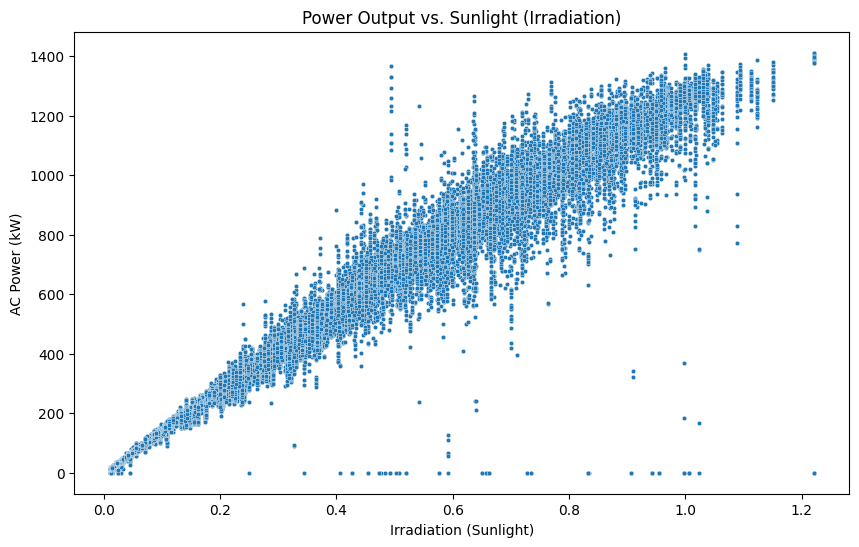

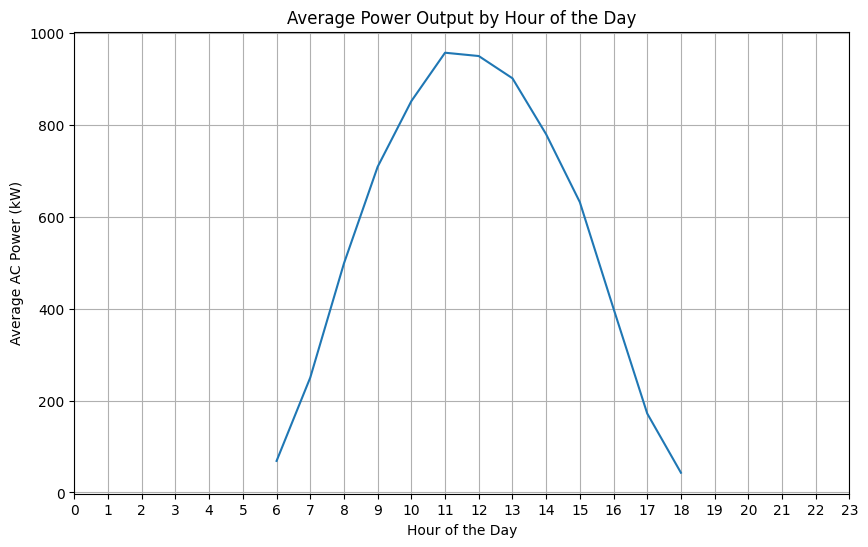

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Graph 1: The "Money Plot" (Sunlight vs. Power) ---
# This shows the most important relationship in your data.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='IRRADIATION', y='AC_POWER', data=df_daylight, s=10)
plt.title('Power Output vs. Sunlight (Irradiation)')
plt.xlabel('Irradiation (Sunlight)')
plt.ylabel('AC Power (kW)')
plt.show()


# --- Graph 2: The Daily Pattern (Hour vs. Power) ---
# This shows the daily cycle of power generation.
plt.figure(figsize=(10, 6))
sns.lineplot(x='hour', y='AC_POWER', data=df_daylight, errorbar=None)
plt.title('Average Power Output by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average AC Power (kW)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()